# In-Game Win Probability: XGBoost (Deployment)

Same architecture as research (v5), retrained on ALL available seasons.
No validation/test split — all data goes to training.
Imports hyperparameters from research notebook's `best_hyperparams.json`.

In [1]:
import sys, os
os.chdir(os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.')

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
from sklearn.metrics import log_loss as sk_log_loss
from sklearn.isotonic import IsotonicRegression

pd.set_option("io.parquet.engine", "pyarrow")

# ── Config ────────────────────────────────────────────────────────────────────
BASE_DIR = Path('.').resolve()
DATA_DIR = BASE_DIR / "data"
ARTIFACTS_DIR = BASE_DIR / "posterior_models" / "deployment"

RANDOM_SEED = 42

TRAIN_SEASONS = list(range(2011, 2027))   # 2010-11 through 2025-26 (all available)
VAL_SEASONS   = []                         # no validation split for deployment
TEST_SEASONS  = []                         # no test split for deployment

REG_PERIOD_SEC = 720
OT_PERIOD_SEC  = 300
TOTAL_REG_SEC  = 4 * REG_PERIOD_SEC

print(f'Artifacts: {ARTIFACTS_DIR}')


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Artifacts: /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/posterior_models/deployment


In [2]:
# All function definitions (I/O, Features, Dataset, Models, Eval, etc.)

# -- I/O Helpers --

def load_posterior_training_set(path=None):
    if path is None:
        path = DATA_DIR / "posterior_training.csv"
    df = pd.read_csv(path, dtype={"game_id": str}, low_memory=False)
    df["game_id"] = df["game_id"].astype(str).str.strip()
    df["season"] = pd.to_numeric(df["season"], errors="coerce").astype(int)
    df["home_win_final"] = df["home_win_final"].astype(int)
    return df

def load_game_predictions(path=None):
    if path is None:
        path = DATA_DIR / "games_predictions_deploy.csv"
    df = pd.read_csv(path, dtype={"game_id": str})
    df["game_id"] = df["game_id"].astype(str).str.strip()
    df["prior_home_wp"] = pd.to_numeric(df["prior_home_wp"], errors="coerce")
    return df


# -- Season Baseline Blending --

TAU_DEFAULT = 200

def load_season_baselines(data_dir=None):
    if data_dir is None:
        data_dir = DATA_DIR
    tg2 = pd.read_csv(data_dir / "training_games2.csv", dtype={"game_id": str}, low_memory=False)
    tg2["game_id"] = tg2["game_id"].astype(str).str.strip()
    baselines = pd.DataFrame({"game_id": tg2["game_id"]})
    for side in ["home", "away"]:
        fgm = pd.to_numeric(tg2[f"{side}_FGM"], errors="coerce").fillna(0)
        fga = pd.to_numeric(tg2[f"{side}_FGA"], errors="coerce").fillna(0).clip(lower=1)
        fg3m = pd.to_numeric(tg2[f"{side}_FG3M"], errors="coerce").fillna(0)
        pts = pd.to_numeric(tg2[f"{side}_PTS"], errors="coerce").fillna(0)
        fta = pd.to_numeric(tg2[f"{side}_FTA"], errors="coerce").fillna(0)
        ft_pct = pd.to_numeric(tg2[f"{side}_FT_PCT"], errors="coerce").fillna(0)
        oreb = pd.to_numeric(tg2[f"{side}_OREB"], errors="coerce").fillna(0)
        to = pd.to_numeric(tg2[f"{side}_TO"], errors="coerce").fillna(0)
        baselines[f"season_{side}_efg"] = (fgm + 0.5 * fg3m) / fga
        baselines[f"season_{side}_ts"] = pts / (2 * (fga + 0.44 * fta)).clip(lower=1)
        poss = (fga + 0.44 * fta - oreb + to).clip(lower=1)
        baselines[f"season_{side}_off_rtg"] = 100 * pts / poss
        baselines[f"season_{side}_ft_pct"] = ft_pct
    baselines = baselines.set_index("game_id")
    print(f"  Season baselines loaded: {len(baselines)} games")
    return baselines


# -- Feature Engineering --

def compute_prior_logit(df):
    df = df.copy()
    p0 = df["prior_home_wp"].clip(0.001, 0.999)
    df["pregame_logit"] = np.log(p0 / (1.0 - p0))
    return df

def compute_time_features(df):
    df = df.copy()
    period = df["period_number"].astype(int)
    sec_period = pd.to_numeric(df["sec_remaining_period"], errors="coerce").fillna(0).astype(float)
    df["is_ot"] = (period > 4).astype(int)
    df["ot_number"] = np.clip(period - 4, 0, None)
    df["t_reg_remaining"] = np.where(
        period <= 4, (4 - period) * REG_PERIOD_SEC + sec_period, 0
    ).astype(float)
    df["t_ot_remaining"] = np.where(period > 4, sec_period, 0).astype(float)
    df["t_reg_norm"] = df["t_reg_remaining"] / TOTAL_REG_SEC
    df["t_reg_log"] = np.log1p(df["t_reg_norm"] * 100) / np.log1p(100)
    df["t_ot_norm"] = np.where(
        df["is_ot"] == 1, df["t_ot_remaining"] / OT_PERIOD_SEC, 0.0
    )
    df["t_ot_log"] = np.where(
        df["is_ot"] == 1,
        np.log1p(df["t_ot_norm"] * 100) / np.log1p(100),
        0.0,
    )
    df["elapsed_game_seconds"] = np.where(
        period <= 4,
        (period - 1) * REG_PERIOD_SEC + (REG_PERIOD_SEC - sec_period),
        TOTAL_REG_SEC + (df["ot_number"] - 1) * OT_PERIOD_SEC + (OT_PERIOD_SEC - sec_period),
    ).astype(float)
    return df

def compute_score_diff(df):
    df = df.copy()
    if "score_diff" not in df.columns:
        df["score_diff"] = (
            pd.to_numeric(df["home_score"], errors="coerce").fillna(0).astype(int)
            - pd.to_numeric(df["away_score"], errors="coerce").fillna(0).astype(int)
        )
    return df

def compute_quality_diffs(df, tau=TAU_DEFAULT):
    df = df.copy()
    if tau and tau > 0 and "season_home_efg" in df.columns:
        total_poss = (df.get("home_poss_to_date", pd.Series(0, index=df.index)).fillna(0)
                      + df.get("away_poss_to_date", pd.Series(0, index=df.index)).fillna(0))
        w = np.exp(-total_poss / tau)
    else:
        w = 0.0
    for feat, season_col, ingame_col in [
        ("efg", "season_{side}_efg", "{side}_efg_pct"),
        ("ts", "season_{side}_ts", "{side}_ts_pct"),
        ("off_rtg", "season_{side}_off_rtg", "{side}_off_rtg"),
    ]:
        for side in ["home", "away"]:
            s_col = season_col.format(side=side)
            i_col = ingame_col.format(side=side)
            ingame = df[i_col].fillna(0)
            if isinstance(w, float) and w == 0.0:
                df[f"_blended_{side}_{feat}"] = ingame
            else:
                season = df.get(s_col, pd.Series(np.nan, index=df.index))
                has_season = season.notna()
                blended = np.where(has_season, w * season.fillna(0) + (1 - w) * ingame, ingame)
                df[f"_blended_{side}_{feat}"] = blended
    df["efg_diff"] = df["_blended_home_efg"] - df["_blended_away_efg"]
    df["ts_diff"] = df["_blended_home_ts"] - df["_blended_away_ts"]
    df["off_rtg_diff"] = df["_blended_home_off_rtg"] - df["_blended_away_off_rtg"]
    df = df.drop(columns=[c for c in df.columns if c.startswith("_blended_")])
    df["ast_diff"] = df["home_ast_to_date"].fillna(0) - df["away_ast_to_date"].fillna(0)
    df["tov_diff"] = df["away_tov_to_date"].fillna(0) - df["home_tov_to_date"].fillna(0)
    df["reb_diff"] = (
        (df["home_oreb_to_date"].fillna(0) + df["home_dreb_to_date"].fillna(0))
        - (df["away_oreb_to_date"].fillna(0) + df["away_dreb_to_date"].fillna(0))
    )
    if "net_pts_last_120" not in df.columns:
        df["net_pts_last_120"] = 0.0
    return df

def compute_late_diffs(df, tau=TAU_DEFAULT):
    df = df.copy()
    df["foul_diff"] = df["away_pf_to_date"].fillna(0) - df["home_pf_to_date"].fillna(0)
    if tau and tau > 0 and "season_home_ft_pct" in df.columns:
        total_poss = (df.get("home_poss_to_date", pd.Series(0, index=df.index)).fillna(0)
                      + df.get("away_poss_to_date", pd.Series(0, index=df.index)).fillna(0))
        w = np.exp(-total_poss / tau)
        home_ft = df["home_ft_pct"].fillna(0)
        away_ft = df["away_ft_pct"].fillna(0)
        s_home = df.get("season_home_ft_pct", pd.Series(np.nan, index=df.index))
        s_away = df.get("season_away_ft_pct", pd.Series(np.nan, index=df.index))
        has_home = s_home.notna()
        has_away = s_away.notna()
        b_home = np.where(has_home, w * s_home.fillna(0) + (1 - w) * home_ft, home_ft)
        b_away = np.where(has_away, w * s_away.fillna(0) + (1 - w) * away_ft, away_ft)
        df["ft_pct_diff"] = b_home - b_away
    else:
        df["ft_pct_diff"] = df["home_ft_pct"].fillna(0) - df["away_ft_pct"].fillna(0)
    df["timeout_diff"] = df["away_timeouts_called"].fillna(0) - df["home_timeouts_called"].fillna(0)
    return df

def compute_bonus_features(df):
    df = df.copy()
    home_pf = df["home_pf_to_date"].fillna(0)
    away_pf = df["away_pf_to_date"].fillna(0)
    period_start_home = df.groupby(["game_id", "period_number"])["home_pf_to_date"].transform("min").fillna(0)
    period_start_away = df.groupby(["game_id", "period_number"])["away_pf_to_date"].transform("min").fillna(0)
    home_pf_period = home_pf - period_start_home
    away_pf_period = away_pf - period_start_away
    threshold = np.where(df["period_number"] > 4, 4, 5)
    home_in_bonus = (away_pf_period >= threshold).astype(int)
    away_in_bonus = (home_pf_period >= threshold).astype(int)
    df["bonus_diff"] = home_in_bonus - away_in_bonus
    return df

def compute_possession(df):
    df = df.copy()
    poss = df["is_home_possession"].values.copy().astype(float)
    df["is_home_poss_signed"] = np.where(
        np.isnan(poss), 0.0, np.where(poss == 0, -1.0, 1.0)
    )
    return df

def compute_prior_features(df, prior_features):
    df = df.copy()
    if prior_features is not None:
        df = df.join(prior_features, on="game_id", how="left")
        df["rest_diff"] = df["rest_diff"].fillna(0)
        df["roster_quality_diff"] = df["roster_quality_diff"].fillna(0)
        df["win_pct_diff"] = df["win_pct_diff"].fillna(0)
    else:
        df["rest_diff"] = 0.0
        df["roster_quality_diff"] = 0.0
        df["win_pct_diff"] = 0.0
    return df

def compute_ingame_extras(df):
    df = df.copy()
    df["stl_diff"] = df.get("home_stl_to_date", pd.Series(0, index=df.index)).fillna(0) - \
                     df.get("away_stl_to_date", pd.Series(0, index=df.index)).fillna(0)
    df["blk_diff"] = df.get("home_blk_to_date", pd.Series(0, index=df.index)).fillna(0) - \
                     df.get("away_blk_to_date", pd.Series(0, index=df.index)).fillna(0)
    df["oreb_diff"] = df.get("home_oreb_to_date", pd.Series(0, index=df.index)).fillna(0) - \
                      df.get("away_oreb_to_date", pd.Series(0, index=df.index)).fillna(0)
    home_fga = df.get("home_fga_to_date", pd.Series(0, index=df.index)).fillna(0).clip(lower=1)
    away_fga = df.get("away_fga_to_date", pd.Series(0, index=df.index)).fillna(0).clip(lower=1)
    home_fg3m = df.get("home_fg3m_to_date", pd.Series(0, index=df.index)).fillna(0)
    away_fg3m = df.get("away_fg3m_to_date", pd.Series(0, index=df.index)).fillna(0)
    df["fg3_pct_diff"] = (home_fg3m / home_fga) - (away_fg3m / away_fga)
    home_fta = df.get("home_fta_to_date", pd.Series(0, index=df.index)).fillna(0)
    away_fta = df.get("away_fta_to_date", pd.Series(0, index=df.index)).fillna(0)
    df["fta_rate_diff"] = (home_fta / home_fga) - (away_fta / away_fga)
    return df

def compute_interaction_features(df):
    df = df.copy()
    t_log = np.where(
        df["is_ot"] == 0,
        df["t_reg_log"].values if "t_reg_log" in df.columns else df["t_reg_norm"].values,
        df["t_ot_log"].values if "t_ot_log" in df.columns else df.get("t_ot_norm", pd.Series(0, index=df.index)).values,
    )
    elapsed = 1.0 - t_log
    df["poss_x_elapsed"] = np.nan_to_num(df["is_home_poss_signed"].values, nan=0.0) * elapsed
    ft = df["pending_ft_signed"].fillna(0).values if "pending_ft_signed" in df.columns else np.zeros(len(df))
    df["ft_x_elapsed"] = ft * elapsed
    return df

def compute_sample_weights(df):
    """Compute per-row sample_weight with clutch upweighting."""
    df = df.copy()
    w = np.ones(len(df), dtype=float)
    final_diff = df.groupby("game_id")["score_diff"].transform("last").abs()
    w = np.where(final_diff <= 4, w * 3.0, np.where(final_diff <= 10, w * 2.0, w))
    t_reg = df["t_reg_remaining"].values if "t_reg_remaining" in df.columns else np.full(len(df), 999)
    w = np.where((t_reg <= 300) & (df["is_ot"] == 0), w * 2.0, w)
    w = np.where((t_reg <= 120) & (df["is_ot"] == 0), w * 2.0, w)
    w = np.where(df["is_ot"] == 1, w * 3.0, w)
    pft = df["pending_ft_signed"].values if "pending_ft_signed" in df.columns else np.zeros(len(df))
    w = np.where(np.abs(pft) >= 1, w * 2.0, w)
    w = np.where(np.abs(pft) >= 2, w * 1.5, w)
    w = np.where(np.abs(pft) >= 3, w * 1.5, w)
    df["sample_weight"] = w
    return df


# -- XGBoost Feature List --
# Single unified model — includes both reg and OT time features.
# XGBoost naturally handles irrelevant features (won't split on t_ot_norm during regulation).

XGBOOST_FEATURES = [
    "score_diff",
    "t_reg_remaining", "t_reg_norm", "t_reg_log",
    "t_ot_remaining", "t_ot_norm", "t_ot_log",
    "is_ot", "ot_number",
    "pregame_logit",
    "efg_diff", "ts_diff", "off_rtg_diff",
    "tov_diff",
    "foul_diff", "ft_pct_diff", "timeout_diff",
    "bonus_diff", "is_home_poss_signed",
    "rest_diff", "roster_quality_diff", "win_pct_diff",
    "stl_diff", "fg3_pct_diff", "fta_rate_diff",
    "pending_ft_signed", "is_dead_ball",
    "poss_x_elapsed", "ft_x_elapsed",
]

STATE_COLS = [
    "game_id", "season", "y",
    "score_diff", "t_reg_remaining", "t_reg_norm", "t_reg_log",
    "t_ot_remaining", "t_ot_norm", "t_ot_log", "is_ot", "ot_number",
    "pregame_logit",
    "efg_diff", "ts_diff", "off_rtg_diff", "ast_diff", "tov_diff", "reb_diff", "net_pts_last_120",
    "foul_diff", "ft_pct_diff", "timeout_diff",
    "bonus_diff",
    "is_home_poss_signed",
    "rest_diff", "roster_quality_diff", "win_pct_diff",
    "stl_diff", "blk_diff", "oreb_diff", "fg3_pct_diff", "fta_rate_diff",
    "pending_ft_signed", "is_dead_ball",
    "poss_x_elapsed", "ft_x_elapsed",
    "sample_weight",
]


# -- Build Dataset --

def build_all(data_dir=DATA_DIR, artifacts_dir=ARTIFACTS_DIR,
              train_seasons=TRAIN_SEASONS, val_seasons=VAL_SEASONS,
              test_seasons=TEST_SEASONS, min_season=2008, tau=TAU_DEFAULT):
    """End-to-end: load CSV -> compute features -> split -> save."""
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    all_seasons = sorted(set(train_seasons + val_seasons + test_seasons))

    print("Loading posterior_training.csv ...")
    raw = load_posterior_training_set(data_dir / "posterior_training.csv")
    print(f"  {len(raw):,} rows, {raw['game_id'].nunique():,} games")

    raw = raw[raw["season"].isin(all_seasons) & (raw["season"] >= min_season)].copy()
    raw = raw.sort_values(["game_id", "play_index"]).reset_index(drop=True)
    print(f"  After season filter: {len(raw):,} rows, {raw['game_id'].nunique():,} games")

    # Replace prior with Kalshi where available
    print("  Replacing prior_home_wp with Kalshi pregame odds (fallback: XGBoost) ...")
    deploy_preds = load_game_predictions()
    if "kalshi_pregame_wp" in deploy_preds.columns:
        kalshi_map = deploy_preds.set_index("game_id")["kalshi_pregame_wp"]
        matched_kalshi = raw["game_id"].isin(kalshi_map.index) & raw["game_id"].map(kalshi_map).notna()
        raw.loc[matched_kalshi, "prior_home_wp"] = raw.loc[matched_kalshi, "game_id"].map(kalshi_map)
        print(f"    Kalshi prior applied to {matched_kalshi.sum()} rows")
    xgb_map = deploy_preds.set_index("game_id")["prior_home_wp"]
    still_missing = raw["prior_home_wp"].isna() & raw["game_id"].isin(xgb_map.index)
    raw.loc[still_missing, "prior_home_wp"] = raw.loc[still_missing, "game_id"].map(xgb_map)
    print(f"    XGBoost fallback applied to {still_missing.sum()} rows")

    # Season baselines
    if tau and tau > 0:
        print(f"  Loading season baselines (tau={tau}) ...")
        baselines = load_season_baselines(data_dir)
        raw = raw.join(baselines, on="game_id", how="left")

    # Prior features
    print("  Loading prior features from training_games4.csv ...")
    tg4 = pd.read_csv(data_dir / "training_games4.csv", dtype={"game_id": str},
                       usecols=["game_id", "home_days_rest", "away_days_rest",
                                "home_10g_player_PLUS_MINUS", "away_10g_player_PLUS_MINUS",
                                "home_win_pct", "away_win_pct"], low_memory=False)
    tg4["game_id"] = tg4["game_id"].astype(str).str.strip()
    tg4["rest_diff"] = tg4["home_days_rest"].fillna(0) - tg4["away_days_rest"].fillna(0)
    tg4["roster_quality_diff"] = tg4["home_10g_player_PLUS_MINUS"].fillna(0) - tg4["away_10g_player_PLUS_MINUS"].fillna(0)
    tg4["win_pct_diff"] = tg4["home_win_pct"].fillna(0.5) - tg4["away_win_pct"].fillna(0.5)
    prior_features = tg4[["game_id", "rest_diff", "roster_quality_diff", "win_pct_diff"]].set_index("game_id")

    print("Computing features ...")
    raw = compute_prior_logit(raw)
    raw = compute_time_features(raw)
    raw = compute_score_diff(raw)
    raw = compute_quality_diffs(raw, tau=tau)
    raw = compute_late_diffs(raw, tau=tau)
    raw = compute_bonus_features(raw)
    raw = compute_possession(raw)
    raw = compute_prior_features(raw, prior_features)
    raw = compute_ingame_extras(raw)
    raw = compute_interaction_features(raw)
    raw = compute_sample_weights(raw)
    raw["y"] = raw["home_win_final"].astype(int)

    states = raw[STATE_COLS].copy()
    before = len(states)
    states = states.dropna(subset=["score_diff", "t_reg_norm", "pregame_logit", "y"])
    states["poss_x_elapsed"] = states["poss_x_elapsed"].fillna(0)
    states["ft_x_elapsed"] = states["ft_x_elapsed"].fillna(0)
    states["pending_ft_signed"] = states["pending_ft_signed"].fillna(0)
    states["is_dead_ball"] = states["is_dead_ball"].fillna(0)
    print(f"  Dropped {before - len(states)} rows with missing critical fields")
    print(f"  Total state rows: {len(states):,}")

    states.to_csv(artifacts_dir / "states.csv", index=False)

    for name, season_list in [("train", train_seasons), ("val", val_seasons), ("test", test_seasons)]:
        mask = states["season"].isin(season_list)
        part = states[mask]
        out = artifacts_dir / f"states_{name}.csv"
        part.to_csv(out, index=False)
        print(f"  Saved {out.name}  ({len(part):,} rows, {part['game_id'].nunique()} games)")

    return states


# -- Evaluation Metrics --

def weighted_log_loss(y, p, w):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    losses = -(y * np.log(p) + (1 - y) * np.log(1 - p))
    return float(np.average(losses, weights=w))

def weighted_brier(y, p, w):
    return float(np.average((y - p) ** 2, weights=w))

def expected_calibration_error(y, p, w, n_bins=20):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    total_w = w.sum()
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi)
        if not mask.any():
            continue
        bw = w[mask].sum()
        ece += (bw / total_w) * abs(np.average(y[mask], weights=w[mask]) - np.average(p[mask], weights=w[mask]))
    return float(ece)

def reliability_curve(y, p, w, n_bins=20):
    bins = np.linspace(0, 1, n_bins + 1)
    centers, empirical, weights = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi)
        if not mask.any():
            continue
        centers.append((lo + hi) / 2)
        empirical.append(np.average(y[mask], weights=w[mask]))
        weights.append(w[mask].sum())
    return np.array(centers), np.array(empirical), np.array(weights)

def add_slice_flags(df):
    df = df.copy()
    df["slice_clutch"] = (df["t_reg_remaining"] <= 120) & (df["score_diff"].abs() <= 5) & (df["is_ot"] == 0)
    df["slice_late_close"] = (df["t_reg_remaining"] <= 300) & (df["score_diff"].abs() <= 10) & (df["is_ot"] == 0)
    df["slice_ot"] = df["is_ot"] == 1
    return df

SLICES = {
    "overall": lambda df: df,
    "clutch": lambda df: df[df["slice_clutch"]],
    "late_close": lambda df: df[df["slice_late_close"]],
    "ot_only": lambda df: df[df["slice_ot"]],
}

def comparison_table(preds, model_cols, split_name="val"):
    rows = []
    for slice_name, slicer in SLICES.items():
        sub = slicer(preds)
        if sub.empty:
            continue
        y = sub["y"].values.astype(float)
        w = sub["sample_weight"].values.astype(float)
        for model_name, col in model_cols.items():
            p = sub[col].values.astype(float)
            rows.append({
                "split": split_name, "slice": slice_name, "model": model_name,
                "n_rows": len(sub), "n_games": sub["game_id"].nunique(),
                "w_logloss": weighted_log_loss(y, p, w),
                "w_brier": weighted_brier(y, p, w),
                "ECE": expected_calibration_error(y, p, w),
            })
    table = pd.DataFrame(rows)
    print(f"\n{'='*80}")
    print(f"  Evaluation -- {split_name}")
    print(f"{'='*80}")
    print(table.to_string(index=False, float_format="%.5f"))
    return table

def plot_reliability(preds, model_cols, slice_name, split_name, artifacts_dir, n_bins=20):
    slicer = SLICES.get(slice_name, lambda df: df)
    sub = slicer(preds)
    if sub.empty:
        return
    y = sub["y"].values.astype(float)
    w = sub["sample_weight"].values.astype(float)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect")
    for model_name, col in model_cols.items():
        p = sub[col].values.astype(float)
        centers, emp, _ = reliability_curve(y, p, w, n_bins=n_bins)
        ax.plot(centers, emp, "o-", markersize=4, label=model_name)
    ax.set_xlabel("Predicted P(home win)")
    ax.set_ylabel("Observed frequency")
    ax.set_title(f"Reliability -- {slice_name} ({split_name})")
    ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    out = artifacts_dir / f"reliability_{slice_name}_{split_name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved {out.name}")


# -- XGBoost Model --

def train_xgboost(train, val, param_grid=None, features=XGBOOST_FEATURES):
    """Train XGBoost with early stopping on WEIGHTED validation loss.
    
    Uses sample_weight for eval so endgame/clutch scenarios matter more
    for early stopping, not just the overall mid-game accuracy.
    """
    X_tr = train[features].values.astype(np.float32)
    y_tr = train["y"].values.astype(int)
    w_tr = train["sample_weight"].values.astype(float)

    X_va = val[features].values.astype(np.float32)
    y_va = val["y"].values.astype(int)
    w_va = val["sample_weight"].values.astype(float)

    if param_grid is None:
        param_grid = [
            # Deep + slow learning (most capacity)
            # Slow learning — let it build many trees
            {"max_depth": 8,  "learning_rate": 0.001,  "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3},
            {"max_depth": 8,  "learning_rate": 0.0005, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3},
            {"max_depth": 8,  "learning_rate": 0.0003, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3},
            {"max_depth": 10, "learning_rate": 0.001,  "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5},
            {"max_depth": 10, "learning_rate": 0.0005, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5},
        ]

    best_model, best_ll, best_params = None, np.inf, None

    for i, params in enumerate(param_grid):
        model = xgb.XGBClassifier(
            n_estimators=20000,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_SEED,
            early_stopping_rounds=300,
            disable_default_eval_metric=True,
            **params,
        )
        model.fit(
            X_tr, y_tr, sample_weight=w_tr,
            eval_set=[(X_va, y_va)],
            sample_weight_eval_set=[w_va],
            verbose=False,
        )
        p_va = model.predict_proba(X_va)[:, 1]
        ll = weighted_log_loss(y_va, p_va, w_va)
        n_trees = model.best_iteration + 1 if model.best_iteration else model.n_estimators
        marker = " <-- best" if ll < best_ll else ""
        print(f"  [{i+1}/{len(param_grid)}] depth={params['max_depth']} "
              f"lr={params['learning_rate']} sub={params['subsample']} "
              f"col={params['colsample_bytree']} "
              f"trees={n_trees} val_ll={ll:.5f}{marker}")
        if ll < best_ll:
            best_ll, best_model, best_params = ll, model, params

    print(f"\n  Best: {best_params} val_logloss={best_ll:.5f}")
    return best_model, best_params, best_ll


def xgb_predict_proba(states, model, features=XGBOOST_FEATURES):
    """Predict P(home_win) using the XGBoost model."""
    X = states[features].values.astype(np.float32)
    p = model.predict_proba(X)[:, 1]
    return np.clip(p, 1e-7, 1 - 1e-7)


def save_model(model, params, artifacts_dir):
    """Save XGBoost model and config."""
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    model.save_model(str(artifacts_dir / "xgb_posterior.json"))
    joblib.dump({"params": params, "features": XGBOOST_FEATURES}, artifacts_dir / "xgb_config.pkl")
    print(f"  XGBoost model saved to {artifacts_dir}")

def load_model(artifacts_dir):
    """Load XGBoost model."""
    model = xgb.XGBClassifier()
    model.load_model(str(artifacts_dir / "xgb_posterior.json"))
    return model


# -- Post-Processing (prior anchoring only) --

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

def _logit(p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1.0 - p))

def postprocess_predictions(p_raw, df, prior_alpha=2.0, terminal_sec=15.0):
    """Apply prior anchoring + data-calibrated terminal convergence.
    
    Terminal convergence uses a sigmoid ramp on score margin:
    as time → 0 and score != 0, blend toward deterministic outcome.
    Strength scales with |score_diff| via sigmoid centered at 2.
    Skipped when FTs are pending (score may still change).
    """
    p_raw = np.asarray(p_raw, dtype=float)
    pregame_logit = df["pregame_logit"].values.astype(float)
    t_reg_norm = df["t_reg_norm"].values.astype(float)
    t_reg_remaining = df["t_reg_remaining"].values.astype(float)
    t_ot_remaining = df.get("t_ot_remaining", pd.Series(0, index=df.index)).values.astype(float)
    is_ot = df["is_ot"].values.astype(int)
    score_diff = df["score_diff"].values.astype(float)
    pending_ft = df["pending_ft_signed"].values.astype(int) if "pending_ft_signed" in df.columns else np.zeros(len(df), dtype=int)

    # Step 1: Prior anchoring (logit-space blend, regulation only)
    prior_weight = np.where(is_ot == 0, np.power(t_reg_norm, prior_alpha), 0.0)
    raw_logit = _logit(p_raw)
    blended_logit = prior_weight * pregame_logit + (1.0 - prior_weight) * raw_logit
    p = _sigmoid(blended_logit)

    # Step 2: Data-calibrated terminal convergence
    time_remaining = np.where(is_ot == 0, t_reg_remaining, t_ot_remaining)
    mask = (time_remaining < terminal_sec) & (score_diff != 0) & (pending_ft == 0)
    if mask.any():
        time_factor = 1.0 - time_remaining[mask] / terminal_sec
        score_factor = 1.0 / (1.0 + np.exp(-1.5 * (np.abs(score_diff[mask]) - 2.0)))
        terminal_weight = time_factor * score_factor
        deterministic = np.where(score_diff[mask] > 0, 1.0, 0.0)
        p[mask] = (1.0 - terminal_weight) * p[mask] + terminal_weight * deterministic

    return np.clip(p, 1e-7, 1 - 1e-7)

def tune_postprocess(val, predict_fn, alpha_grid=None, terminal_grid=None):
    if alpha_grid is None:
        alpha_grid = [1.0, 2.0, 4.0, 10.0, 100.0]
    if terminal_grid is None:
        terminal_grid = [10.0, 15.0, 20.0, 30.0]
    p_raw = predict_fn(val)
    y = val["y"].values.astype(float)
    w = val["sample_weight"].values.astype(float)
    raw_ll = weighted_log_loss(y, p_raw, w)
    best_ll = np.inf
    best_alpha, best_terminal = alpha_grid[0], terminal_grid[0]
    results = []
    for alpha in alpha_grid:
        for tsec in terminal_grid:
            p_post = postprocess_predictions(p_raw, val, prior_alpha=alpha, terminal_sec=tsec)
            ll = weighted_log_loss(y, p_post, w)
            results.append({"alpha": alpha, "terminal_sec": tsec, "logloss": ll})
            if ll < best_ll:
                best_ll, best_alpha, best_terminal = ll, alpha, tsec
    print(f"  Postprocess tuning: raw logloss = {raw_ll:.5f}")
    print(f"  Best: alpha={best_alpha}, terminal_sec={best_terminal}, logloss={best_ll:.5f} (delta={best_ll - raw_ll:+.5f})")
    return {"best_alpha": best_alpha, "best_terminal_sec": best_terminal,
            "best_logloss": best_ll, "raw_logloss": raw_ll, "results": results}


# -- Calibration --

def fit_isotonic(y, p, w):
    iso = IsotonicRegression(y_min=1e-7, y_max=1 - 1e-7, out_of_bounds="clip")
    iso.fit(p, y, sample_weight=w)
    return iso


print("XGBoost posterior modeling functions loaded")
print(f"  Features: {len(XGBOOST_FEATURES)}")
print(f"  State cols: {len(STATE_COLS)}")


XGBoost posterior modeling functions loaded
  Features: 29
  State cols: 38


## Step 1 -- Build Dataset

Loads `posterior_training.csv` (3.6M rows, 26K games), computes features:
- `pregame_logit` = logit(prior_home_wp) from the trained prior model
- Time features from `period_number` + `sec_remaining_period`
- 7 game-quality diffs (efg, ts, off_rtg, ast, tov, reb, net_pts_last_120)
- 3 late-game diffs (foul, ft_pct, timeout)
- Bonus indicator (bonus_diff)
- Signed possession indicator

Filters to train/val/test seasons, saves per-split parquet files.

In [3]:
states = build_all()

Loading posterior_training.csv ...
  2,050,617 rows, 11,145 games
  After season filter: 2,050,617 rows, 11,145 games
  Replacing prior_home_wp with Kalshi pregame odds (fallback: XGBoost) ...
    XGBoost fallback applied to 0 rows
  Loading season baselines (tau=200) ...
  Season baselines loaded: 30260 games
  Loading prior features from training_games4.csv ...
Computing features ...
  Dropped 0 rows with missing critical fields
  Total state rows: 2,050,617
  Saved states_train.csv  (2,050,617 rows, 11145 games)
  Saved states_val.csv  (0 rows, 0 games)
  Saved states_test.csv  (0 rows, 0 games)


In [4]:
# Load training data (all seasons)
train = pd.read_csv(ARTIFACTS_DIR / 'states_train.csv', dtype={"game_id": str})

print(f'Train: {len(train):>10,} rows  {train["game_id"].nunique():>5} games')
print(f'Seasons: {sorted(train["season"].unique())}')
print(f'Features: {len(XGBOOST_FEATURES)}')


Train:  2,050,617 rows  11145 games
Seasons: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Features: 29


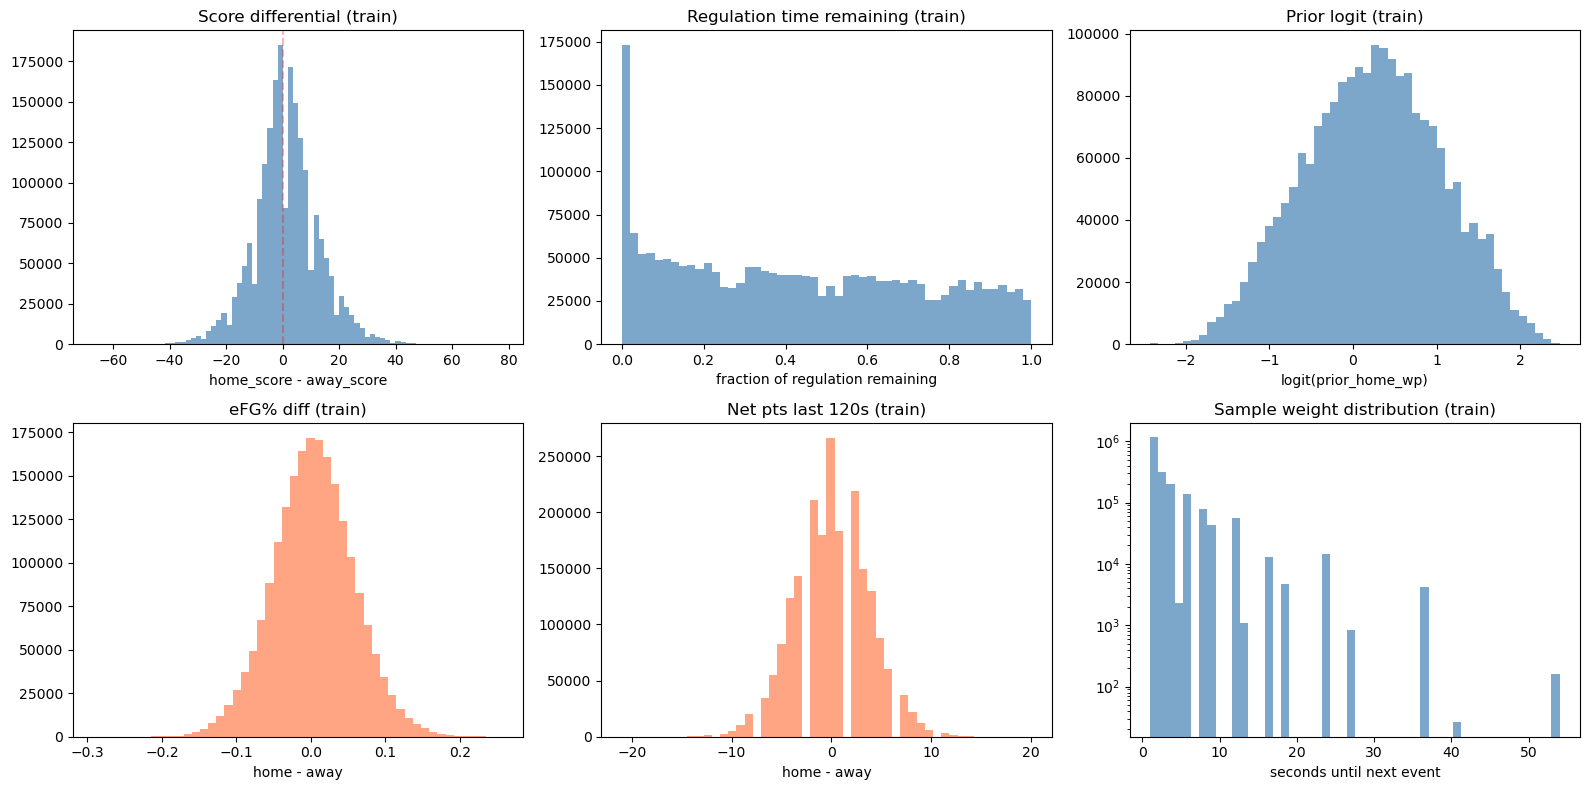

In [5]:
# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0,0].hist(train['score_diff'], bins=80, alpha=0.7, color='steelblue')
axes[0,0].set_title('Score differential (train)')
axes[0,0].set_xlabel('home_score - away_score')
axes[0,0].axvline(0, color='red', alpha=0.3, ls='--')

axes[0,1].hist(train['t_reg_norm'], bins=50, alpha=0.7, color='steelblue')
axes[0,1].set_title('Regulation time remaining (train)')
axes[0,1].set_xlabel('fraction of regulation remaining')

axes[0,2].hist(train['pregame_logit'], bins=50, alpha=0.7, color='steelblue')
axes[0,2].set_title('Prior logit (train)')
axes[0,2].set_xlabel('logit(prior_home_wp)')

axes[1,0].hist(train['efg_diff'].dropna(), bins=50, alpha=0.7, color='coral')
axes[1,0].set_title('eFG% diff (train)')
axes[1,0].set_xlabel('home - away')

axes[1,1].hist(train['net_pts_last_120'].dropna(), bins=50, alpha=0.7, color='coral')
axes[1,1].set_title('Net pts last 120s (train)')
axes[1,1].set_xlabel('home - away')

w = train['sample_weight']
axes[1,2].hist(w[w > 0], bins=50, alpha=0.7, color='steelblue', log=True)
axes[1,2].set_title('Sample weight distribution (train)')
axes[1,2].set_xlabel('seconds until next event')

plt.tight_layout()
plt.show()

## Step 2 -- Train XGBoost

Single unified model (no separate reg/OT). XGBoost naturally handles
multi-way interactions between score, time, possession, and pending FTs.

In [6]:
# -- Load best hyperparameters from research notebook --
import json as _json

RESEARCH_DIR = BASE_DIR / 'posterior_models' / 'research'
hp_path = RESEARCH_DIR / 'best_hyperparams.json'

with open(hp_path) as f:
    hp = _json.load(f)

print(f'Loaded hyperparameters from {hp_path}:')
for k, v in hp.items():
    print(f'  {k}: {v}')

xgb_params = hp['xgb_params']
best_alpha = hp['prior_alpha']
best_terminal = hp.get('terminal_sec', 30.0)

# Train on ALL data with research hyperparams (no early stopping — use fixed n_estimators)
# Use the same tree count as research found optimal
print(f'\nTraining deployment XGBoost on {len(train):,} rows...')

xgb_model = xgb.XGBClassifier(
    n_estimators=10000,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_SEED,
    **xgb_params,
)
# Use train as both train and eval (no separate val — just monitor convergence)
X_tr = train[XGBOOST_FEATURES].values.astype(np.float32)
y_tr = train["y"].values.astype(int)
w_tr = train["sample_weight"].values.astype(float)

xgb_model.fit(X_tr, y_tr, sample_weight=w_tr, verbose=False)
n_trees = xgb_model.n_estimators
print(f'Trained {n_trees} trees')

# Feature importance
fi = pd.Series(xgb_model.feature_importances_, index=XGBOOST_FEATURES).sort_values(ascending=False)
print('\nFeature importance (top 15):')
for feat, imp in fi.head(15).items():
    print(f'  {feat:<25s} {imp:.4f}')

# Save
save_model(xgb_model, xgb_params, ARTIFACTS_DIR)

# Save hyperparams for this deployment
deploy_hp = {
    "prior_alpha": best_alpha,
    "terminal_sec": best_terminal,
    "tau": TAU_DEFAULT,
    "xgb_params": xgb_params,
}
with open(ARTIFACTS_DIR / "best_hyperparams.json", "w") as f:
    _json.dump(deploy_hp, f, indent=2)
print(f'\nSaved deployment hyperparameters')


Loaded hyperparameters from /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/posterior_models/research/best_hyperparams.json:
  prior_alpha: 2.0
  terminal_sec: 30.0
  tau: 200
  xgb_params: {'max_depth': 8, 'learning_rate': 0.001, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3}

Training deployment XGBoost on 2,050,617 rows...
Trained 10000 trees

Feature importance (top 15):
  score_diff                0.2809
  off_rtg_diff              0.0810
  t_reg_norm                0.0755
  t_reg_log                 0.0727
  t_reg_remaining           0.0690
  poss_x_elapsed            0.0484
  pregame_logit             0.0315
  ft_x_elapsed              0.0283
  is_home_poss_signed       0.0235
  is_ot                     0.0233
  win_pct_diff              0.0223
  roster_quality_diff       0.0211
  t_ot_remaining            0.0201
  ts_diff                   0.0199
  t_ot_norm                 0.0194
  XGBoost model saved to /Users/danielyang/Desktop/Extra_Curricular

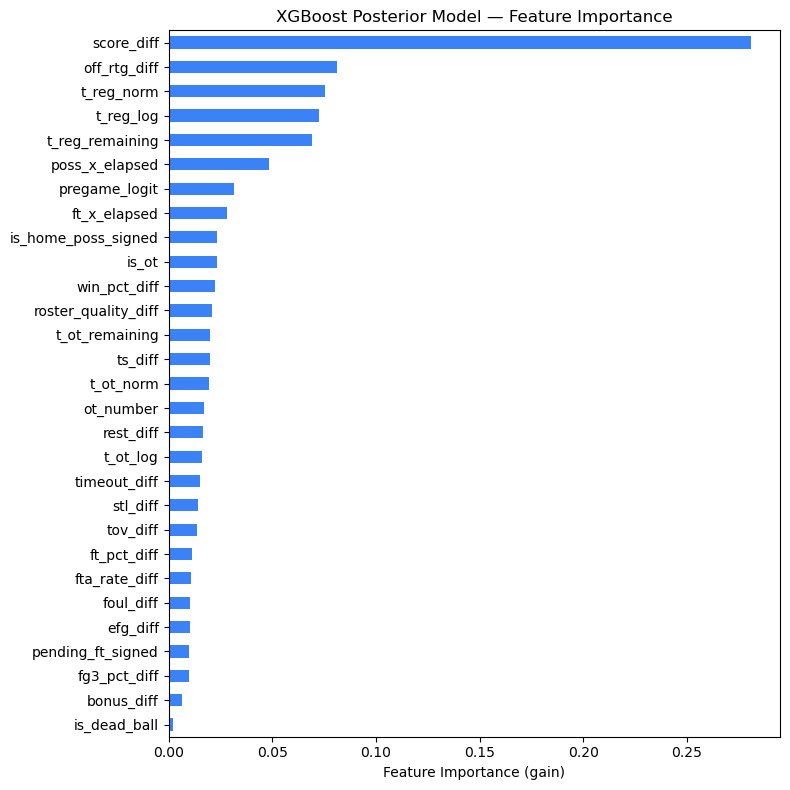

In [13]:
# Feature importance bar chart
fi = pd.Series(xgb_model.feature_importances_, index=XGBOOST_FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 8))
fi.plot(kind='barh', ax=ax, color='#3b82f6')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost Posterior Model — Feature Importance')
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Calibration: fit isotonic regressors on training set
xgb_loaded = load_model(ARTIFACTS_DIR)

def xgb_pred(df):
    return xgb_predict_proba(df, xgb_loaded)

def xgb_pred_post(df):
    p_raw = xgb_pred(df)
    return postprocess_predictions(p_raw, df, best_alpha, best_terminal)

# Fit on full training set
p_train_post = xgb_pred_post(train)
y_train = train["y"].values.astype(float)
w_train = train["sample_weight"].values.astype(float)

iso_xgb = fit_isotonic(y_train, p_train_post, w_train)
iso_xgb_raw = fit_isotonic(y_train, xgb_pred(train), w_train)

joblib.dump(iso_xgb, ARTIFACTS_DIR / "iso_xgb_post.pkl")
joblib.dump(iso_xgb_raw, ARTIFACTS_DIR / "iso_xgb.pkl")

ll = weighted_log_loss(y_train, iso_xgb.predict(p_train_post), w_train)
print(f'Train calibrated logloss: {ll:.5f}')
print('Saved isotonic calibrators')


Train calibrated logloss: 0.31370
Saved isotonic calibrators


In [15]:
# Monotonicity check
sample = train.sample(min(2000, len(train)), random_state=42).copy()
p_orig = xgb_pred(sample)
bumped = sample.copy()
bumped["score_diff"] = bumped["score_diff"] + 1
p_bump = xgb_pred(bumped)
violations = int((p_bump < p_orig - 1e-8).sum())
print(f"Monotonicity check (score_diff +1): {violations}/{len(sample)} violations")


Monotonicity check (score_diff +1): 65/2000 violations


In [16]:
# Boundary / sanity checks
print('=== Boundary Condition Verification ===\n')

for sd in [-5, -3, -2, -1, 0, 1, 2, 3, 5]:
    row = train.iloc[[0]].copy()
    for c in XGBOOST_FEATURES:
        row[c] = 0
    row["score_diff"] = sd
    row["t_reg_remaining"] = 2.0
    row["t_reg_norm"] = 2.0 / 2880.0
    row["t_reg_log"] = float(np.log1p(2.0/2880.0 * 100) / np.log1p(100))
    row["pregame_logit"] = 0.0
    row["is_home_poss_signed"] = 1.0
    row["poss_x_elapsed"] = 1.0 * (1 - row["t_reg_log"].values[0])
    p = xgb_pred(row)[0]
    p_post = postprocess_predictions(np.array([p]), row, best_alpha, best_terminal)[0]
    p_cal = iso_xgb.predict([p_post])[0]
    print(f"  score_diff={sd:+2d}, 2s left, home ball: raw={p:.3f} post={p_post:.3f} cal={p_cal:.3f}")


=== Boundary Condition Verification ===

  score_diff=-5, 2s left, home ball: raw=0.035 post=0.003 cal=0.000
  score_diff=-3, 2s left, home ball: raw=0.088 post=0.021 cal=0.000
  score_diff=-2, 2s left, home ball: raw=0.141 post=0.075 cal=0.010
  score_diff=-1, 2s left, home ball: raw=0.302 post=0.250 cal=0.144
  score_diff=+0, 2s left, home ball: raw=0.597 post=0.597 cal=0.598
  score_diff=+1, 2s left, home ball: raw=0.855 post=0.880 cal=0.975
  score_diff=+2, 2s left, home ball: raw=0.918 post=0.956 cal=0.998
  score_diff=+3, 2s left, home ball: raw=0.965 post=0.992 cal=1.000
  score_diff=+5, 2s left, home ball: raw=0.987 post=0.999 cal=1.000


## Step 6 -- Sample Game Prediction Output + Kalshi Comparison

Build play-by-play predictions for a 2025-26 game and compare against Kalshi implied odds.
Features are reconstructed from raw PBP data (games_live/2026/) since the 2025-26 season is not in the posterior training set.

  Season baselines loaded: 30260 games
Blend tau = 200, Season baselines: 30260 games, Prior features: 19562 games
Game:    401810391  (2026-01-09)
Matchup: MEM (home) vs OKC (away)
Prior:   P(home win) = 0.4362
Outcome: Away Win
Rows:    512
Kalshi trades: 20257

Saved plot to /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/data/samples/winprob_trace_kalshi_401810391.png


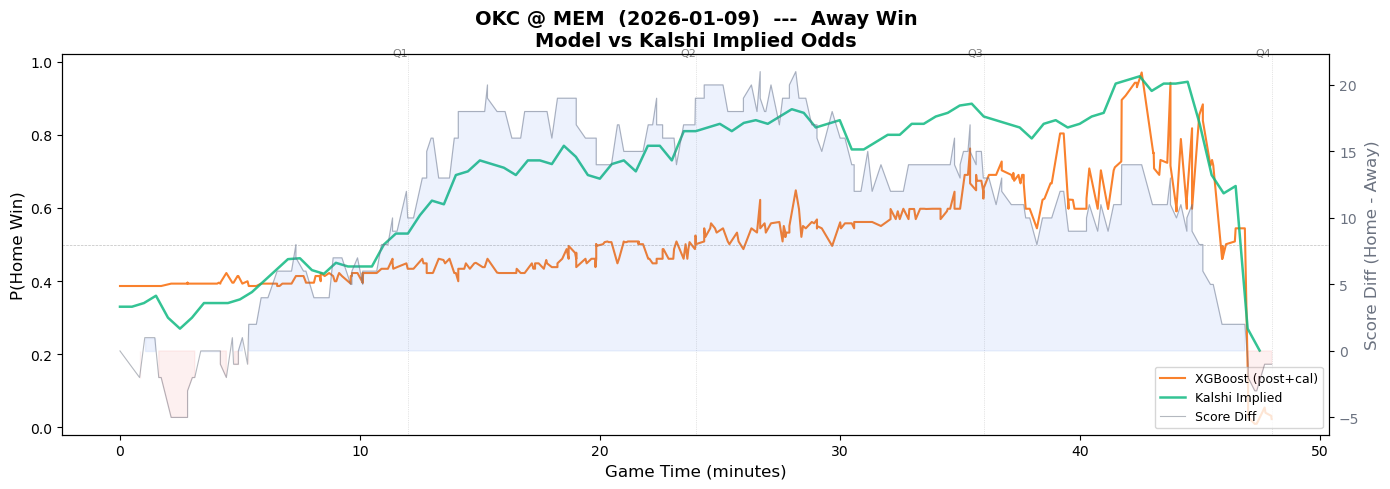

Saved CSV to /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/data/samples/pbp_prediction_v4_kalshi_401810391.csv  (512 rows)

Every 10th play:


,period_number,sec_remaining_period,home_score,away_score,score_diff,p_xgb_post_cal
0,1,720.0,0.0,0.0,0.0,0.38661
10,1,592.0,3.0,8.0,-5.0,0.39309
20,1,554.0,3.0,8.0,-5.0,0.39309
30,1,505.0,8.0,8.0,0.0,0.39309
40,1,454.0,8.0,10.0,-2.0,0.42210
50,1,414.0,13.0,12.0,1.0,0.39309
60,1,327.0,20.0,14.0,6.0,0.39309
70,1,280.0,22.0,14.0,8.0,0.41387
80,1,218.0,22.0,18.0,4.0,0.42210
90,1,165.0,25.0,18.0,7.0,0.41387


In [17]:
# Build play-by-play predictions for a 2025-26 game + Kalshi implied odds comparison

# -- Load season baselines + tau from saved config --
_xgb_config = joblib.load(ARTIFACTS_DIR / 'xgb_config.pkl')
BLEND_TAU = TAU_DEFAULT
SEASON_BASELINES = load_season_baselines()

# Load prior features (rest, roster quality) from training_games4
_tg4 = pd.read_csv(DATA_DIR / "training_games4.csv", dtype={"game_id": str},
                    usecols=["game_id", "home_days_rest", "away_days_rest",
                             "home_10g_player_PLUS_MINUS", "away_10g_player_PLUS_MINUS",
                             "home_win_pct", "away_win_pct"],
                    low_memory=False)
_tg4["game_id"] = _tg4["game_id"].astype(str).str.strip()
_tg4["rest_diff"] = _tg4["home_days_rest"].fillna(0) - _tg4["away_days_rest"].fillna(0)
_tg4["roster_quality_diff"] = _tg4["home_10g_player_PLUS_MINUS"].fillna(0) - _tg4["away_10g_player_PLUS_MINUS"].fillna(0)
_tg4["win_pct_diff"] = _tg4["home_win_pct"].fillna(0.5) - _tg4["away_win_pct"].fillna(0.5)
PRIOR_FEATURES = _tg4[["game_id", "rest_diff", "roster_quality_diff", "win_pct_diff"]].set_index("game_id")

print(f'Blend tau = {BLEND_TAU}, Season baselines: {len(SEASON_BASELINES)} games, Prior features: {len(PRIOR_FEATURES)} games')

# -- Helper: build game features from raw PBP --

def build_game_from_pbp(game_id, data_dir=DATA_DIR):
    """Build posterior-model features from a raw PBP CSV (games_live/2026/)."""
    pbp_path = list((data_dir / 'games_live' / '2026').glob(f'{game_id}_*.csv'))[0]
    pbp = pd.read_csv(pbp_path).sort_values('game_play_number').reset_index(drop=True)

    # Fix "End Period" rows: end_quarter_seconds_remaining is erroneously 720 instead of 0
    end_period_mask = pbp['type_text'].str.contains('End Period', na=False)
    pbp.loc[end_period_mask, 'end_quarter_seconds_remaining'] = 0.0

    home_tid = pbp['home_team_id'].iloc[0]
    away_tid = pbp['away_team_id'].iloc[0]
    is_home = pbp['team_id'] == home_tid
    is_away = pbp['team_id'] == away_tid

    # Play-type flags
    fg_att  = pbp['shooting_play'].fillna(False) & (pbp['points_attempted'] >= 2)
    fg_made = pbp['scoring_play'].fillna(False) & (pbp['score_value'] >= 2)
    fg3_made = pbp['scoring_play'].fillna(False) & (pbp['score_value'] == 3)
    ft_att  = pbp['shooting_play'].fillna(False) & (pbp['points_attempted'] == 1)
    ft_made = pbp['scoring_play'].fillna(False) & (pbp['score_value'] == 1)
    oreb = pbp['type_text'].str.contains('Offensive Rebound', na=False)
    dreb = pbp['type_text'].str.contains('Defensive Rebound', na=False)
    tov  = pbp['short_description'].str.contains('Turnover', na=False)
    ast  = pbp['text'].str.contains('assists', case=False, na=False) & pbp['scoring_play'].fillna(False)
    stl  = pbp['type_text'].str.contains('Steal', na=False)
    blk  = pbp['type_text'].str.contains('Block', na=False)
    foul = pbp['short_description'].str.contains('Foul', na=False)
    timeout = pbp['short_description'].str.contains('Timeout', na=False)

    # Cumulative stat columns
    cols = {}
    for prefix, mask in [('home', is_home), ('away', is_away)]:
        cols[f'{prefix}_fga_to_date'] = (fg_att & mask).cumsum()
        cols[f'{prefix}_fgm_to_date'] = (fg_made & mask).cumsum()
        cols[f'{prefix}_fg3m_to_date'] = (fg3_made & mask).cumsum()
        cols[f'{prefix}_fta_to_date'] = (ft_att & mask).cumsum()
        cols[f'{prefix}_ftm_to_date'] = (ft_made & mask).cumsum()
        cols[f'{prefix}_oreb_to_date'] = (oreb & mask).cumsum()
        cols[f'{prefix}_dreb_to_date'] = (dreb & mask).cumsum()
        cols[f'{prefix}_tov_to_date'] = (tov & mask).cumsum()
        cols[f'{prefix}_ast_to_date'] = (ast & mask).cumsum()
        cols[f'{prefix}_stl_to_date'] = (stl & mask).cumsum()
        cols[f'{prefix}_blk_to_date'] = (blk & mask).cumsum()
        cols[f'{prefix}_pf_to_date'] = (foul & mask).cumsum()
        cols[f'{prefix}_timeouts_called'] = (timeout & mask).cumsum()

    # Derived percentages
    for prefix in ['home', 'away']:
        fga  = cols[f'{prefix}_fga_to_date'].clip(lower=1)
        fta  = cols[f'{prefix}_fta_to_date'].clip(lower=1)
        fgm  = cols[f'{prefix}_fgm_to_date']
        ftm  = cols[f'{prefix}_ftm_to_date']
        fg3m = cols[f'{prefix}_fg3m_to_date']
        pts  = pbp[f'{prefix}_score']
        cols[f'{prefix}_fg_pct']  = fgm / fga
        cols[f'{prefix}_ft_pct']  = ftm / fta
        cols[f'{prefix}_efg_pct'] = (fgm + 0.5 * fg3m) / fga
        cols[f'{prefix}_ts_pct']  = pts / (2 * (fga + 0.44 * cols[f'{prefix}_fta_to_date'])).clip(lower=1)
        poss = (cols[f'{prefix}_fga_to_date']
                + 0.44 * cols[f'{prefix}_fta_to_date']
                - cols[f'{prefix}_oreb_to_date']
                + cols[f'{prefix}_tov_to_date']).clip(lower=1)
        cols[f'{prefix}_poss_to_date'] = poss
        cols[f'{prefix}_off_rtg'] = 100 * pts / poss

    # Possession tracking (simplified heuristic)
    poss_arr = np.full(len(pbp), np.nan)
    team_ids  = pbp['team_id'].values
    short_d   = pbp['short_description'].fillna('').values
    type_t    = pbp['type_text'].fillna('').values
    shooting  = pbp['shooting_play'].fillna(False).values
    for i in range(len(pbp)):
        tid = team_ids[i]
        if pd.isna(tid):
            continue
        if shooting[i] or 'Turnover' in short_d[i]:
            poss_arr[i] = 1.0 if tid == home_tid else 0.0
        elif 'Rebound' in type_t[i]:
            poss_arr[i] = 1.0 if tid == home_tid else 0.0

    # Net points last 120 game-seconds
    game_sec = np.nan_to_num(pbp['end_game_seconds_remaining'].values.astype(float), nan=0.0)
    home_sc  = pbp['home_score'].values.astype(float)
    away_sc  = pbp['away_score'].values.astype(float)
    net_pts  = np.zeros(len(pbp))
    for i in range(len(pbp)):
        j = i
        while j > 0 and game_sec[j - 1] - game_sec[i] <= 120:
            j -= 1
        net_pts[i] = (home_sc[i] - home_sc[j]) - (away_sc[i] - away_sc[j])

    # Game metadata from prior model predictions
    gp = load_game_predictions()
    ginfo = gp[gp['game_id'] == game_id].iloc[0]

    result = pd.DataFrame({
        'game_id': game_id,
        'season': 2026,
        'game_date': ginfo['game_date'],
        'play_index': range(len(pbp)),
        'prior_home_wp': ginfo['prior_home_wp'],
        'home_score': home_sc,
        'away_score': away_sc,
        'score_diff': home_sc - away_sc,
        'period_number': pbp['period_number'].values,
        'sec_remaining_game': np.nan_to_num(game_sec, nan=0.0),
        'sec_remaining_period': np.nan_to_num(pbp['end_quarter_seconds_remaining'].values.astype(float), nan=0.0),
        'is_overtime': (pbp['period_number'] > 4).astype(int).values,
        'is_home_possession': poss_arr,
        'net_pts_last_120': net_pts,
        'home_win_final': int(home_sc[-1] > away_sc[-1]),
        'sample_weight': 1.0,
    })
    for k, v in cols.items():
        result[k] = v.values if hasattr(v, 'values') else v
    # Default pending FT / dead ball (not detectable from simplified PBP path)
    result['pending_ft_signed'] = 0
    result['is_dead_ball'] = 0
    result['poss_x_elapsed'] = 0.0
    result['ft_x_elapsed'] = 0.0

    result['wallclock'] = pbp['wallclock'].values

    # Attach season baselines for blending
    if game_id in SEASON_BASELINES.index:
        for col in SEASON_BASELINES.columns:
            result[col] = SEASON_BASELINES.loc[game_id, col]

    # Attach prior features (rest, roster quality)
    if game_id in PRIOR_FEATURES.index:
        for col in PRIOR_FEATURES.columns:
            result[col] = PRIOR_FEATURES.loc[game_id, col]
    else:
        result["rest_diff"] = 0.0
        result["roster_quality_diff"] = 0.0
        result["win_pct_diff"] = 0.0

    return result


def load_kalshi_implied(game_id, data_dir=DATA_DIR):
    """Load Kalshi trade data and compute home-win implied probability."""
    kalshi_path = list((data_dir / 'kalshi_live').glob(f'{game_id}_*.csv'))[0]
    kalshi = pd.read_csv(kalshi_path)
    kalshi['timestamp'] = pd.to_datetime(kalshi['timestamp'], format='ISO8601')
    home_mid = (kalshi['home_high_cents'] + kalshi['home_low_cents']) / 2
    away_mid = (kalshi['away_high_cents'] + kalshi['away_low_cents']) / 2
    kalshi['home_implied'] = np.where(
        kalshi['home_volume'] > 0, home_mid,
        np.where(kalshi['away_volume'] > 0, 1 - away_mid, np.nan)
    )
    return kalshi.dropna(subset=['home_implied'])


# -- Build game features for a 2025-26 game --

SAMPLE_GAME_ID = '401810391'  # OKC @ MEM, Jan 9 2026, decided by 1 pt

game_raw = build_game_from_pbp(SAMPLE_GAME_ID)
for fn in [compute_prior_logit, compute_time_features, compute_score_diff]:
    game_raw = fn(game_raw)
game_raw = compute_quality_diffs(game_raw, tau=BLEND_TAU)
game_raw = compute_late_diffs(game_raw, tau=BLEND_TAU)
game_raw = compute_ingame_extras(game_raw)
for fn in [compute_bonus_features, compute_possession, compute_sample_weights]:
    game_raw = fn(game_raw)
game_raw['y'] = game_raw['home_win_final'].astype(int)

# Predict -- raw + postprocessed + calibrated
game_raw['p_xgb']  = xgb_pred(game_raw)
game_raw['p_xgb_cal']  = iso_xgb_raw.predict(game_raw['p_xgb'].values)
game_raw['p_xgb_post']  = xgb_pred_post(game_raw)
game_raw['p_xgb_post_cal']  = iso_xgb.predict(game_raw['p_xgb_post'].values)

# Metadata
gp = load_game_predictions()
info = gp[gp['game_id'] == SAMPLE_GAME_ID].iloc[0]
home, away = info['home_team'], info['away_team']
prior_wp = game_raw['prior_home_wp'].iloc[0]
outcome = 'Home Win' if game_raw['y'].iloc[0] == 1 else 'Away Win'
date = game_raw['game_date'].iloc[0]

print(f'Game:    {SAMPLE_GAME_ID}  ({date})')
print(f'Matchup: {home} (home) vs {away} (away)')
print(f'Prior:   P(home win) = {prior_wp:.4f}')
print(f'Outcome: {outcome}')
print(f'Rows:    {len(game_raw)}')

# -- Load + align Kalshi data --

kalshi = load_kalshi_implied(SAMPLE_GAME_ID)
print(f'Kalshi trades: {len(kalshi)}')

# Compute elapsed game time in minutes
total_periods = game_raw['period_number'].max()
elapsed = []
for _, row in game_raw.iterrows():
    p = int(row['period_number'])
    sec_left = row['sec_remaining_period']
    if p <= 4:
        elapsed_sec = (p - 1) * REG_PERIOD_SEC + (REG_PERIOD_SEC - sec_left)
    else:
        elapsed_sec = TOTAL_REG_SEC + (p - 5) * OT_PERIOD_SEC + (OT_PERIOD_SEC - sec_left)
    elapsed.append(elapsed_sec / 60.0)
game_raw['elapsed_min'] = elapsed

# Map Kalshi timestamps to game elapsed time via PBP wallclock interpolation
game_raw['wallclock_dt'] = pd.to_datetime(game_raw['wallclock'], utc=True, format='ISO8601')
wc_sec = game_raw['wallclock_dt'].astype(np.int64).values / 1e9
el_min = game_raw['elapsed_min'].values
kalshi_sec = kalshi['timestamp'].astype(np.int64).values / 1e9
kalshi['elapsed_min'] = np.interp(kalshi_sec, wc_sec, el_min)

# Bin Kalshi into 30-second intervals and take median
max_min = game_raw['elapsed_min'].max()
bin_edges = np.arange(0, max_min + 0.5, 0.5)
kalshi_sorted = kalshi.sort_values('elapsed_min')
kalshi_sorted['bin'] = pd.cut(kalshi_sorted['elapsed_min'], bins=bin_edges, labels=bin_edges[:-1])
kalshi_binned = kalshi_sorted.groupby('bin', observed=True)['home_implied'].median().reset_index()
kalshi_binned.columns = ['elapsed_min', 'home_implied']
kalshi_binned['elapsed_min'] = kalshi_binned['elapsed_min'].astype(float)
kalshi_binned = kalshi_binned.dropna()

# -- Plot: Win Probability + Score Differential + Kalshi --

fig, ax1 = plt.subplots(figsize=(14, 5))

# Win probability lines (left y-axis)
ax1.plot(game_raw['elapsed_min'], game_raw['p_xgb_post_cal'], color='#f97316',
         linewidth=1.5, alpha=0.9, label='XGBoost (post+cal)')
ax1.plot(kalshi_binned['elapsed_min'], kalshi_binned['home_implied'],
         color='#10b981', linewidth=1.8, alpha=0.85, label='Kalshi Implied')
ax1.axhline(0.5, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.set_ylabel('P(Home Win)', fontsize=12)
ax1.set_ylim(-0.02, 1.02)
ax1.set_xlabel('Game Time (minutes)', fontsize=12)

# Score differential (right y-axis)
ax2 = ax1.twinx()
ax2.fill_between(game_raw['elapsed_min'], game_raw['score_diff'], 0,
                 where=(game_raw['score_diff'] >= 0), color='#2563eb', alpha=0.08)
ax2.fill_between(game_raw['elapsed_min'], game_raw['score_diff'], 0,
                 where=(game_raw['score_diff'] < 0), color='#ef4444', alpha=0.08)
ax2.plot(game_raw['elapsed_min'], game_raw['score_diff'], color='#6b7280',
         linewidth=0.8, alpha=0.5, label='Score Diff')
ax2.set_ylabel('Score Diff (Home - Away)', fontsize=12, color='#6b7280')
ax2.tick_params(axis='y', labelcolor='#6b7280')

# Quarter / OT lines
for q in range(1, 5):
    qx = q * REG_PERIOD_SEC / 60.0
    if qx <= max_min:
        ax1.axvline(qx, color='grey', linewidth=0.5, linestyle=':', alpha=0.4)
        ax1.text(qx, 1.01, f'Q{q}', ha='right', va='bottom', fontsize=8, color='grey')
for ot in range(1, max(total_periods - 3, 0)):
    otx = (TOTAL_REG_SEC + ot * OT_PERIOD_SEC) / 60.0
    if otx <= max_min:
        ax1.axvline(otx, color='grey', linewidth=0.5, linestyle=':', alpha=0.4)
        ax1.text(otx, 1.01, f'OT{ot}', ha='right', va='bottom', fontsize=8, color='grey')

ax1.set_title(f'{away} @ {home}  ({date})  ---  {outcome}\nModel vs Kalshi Implied Odds',
              fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)
fig.tight_layout()

SAMPLES_DIR = DATA_DIR / 'samples'
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)
fig_path = SAMPLES_DIR / f'winprob_trace_kalshi_{SAMPLE_GAME_ID}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'\nSaved plot to {fig_path}')
plt.show()

# -- Save prediction CSV --
out_cols = [
    'game_id', 'game_date',
    'period_number', 'sec_remaining_period',
    'home_score', 'away_score', 'score_diff',
    'pregame_logit', 'is_ot', 'ot_number',
    'efg_diff', 'ts_diff', 'off_rtg_diff', 'net_pts_last_120',
    'foul_diff', 'is_home_poss_signed',
    'p_xgb', 'p_xgb_cal',
    'p_xgb_post', 'p_xgb_post_cal',
    'y',
]
pbp_out = game_raw[out_cols].copy()
pbp_out.insert(1, 'home_team', home)
pbp_out.insert(2, 'away_team', away)
pbp_out = pbp_out.round({
    'pregame_logit': 4, 'efg_diff': 4, 'ts_diff': 4, 'off_rtg_diff': 2,
    'net_pts_last_120': 1, 'foul_diff': 0,
    'p_xgb': 5, 'p_xgb_cal': 5,
    'p_xgb_post': 5, 'p_xgb_post_cal': 5,
})

out_path = SAMPLES_DIR / f'pbp_prediction_v4_kalshi_{SAMPLE_GAME_ID}.csv'
pbp_out.to_csv(out_path, index=False)
print(f'Saved CSV to {out_path}  ({len(pbp_out)} rows)')

# Show every 10th row
print(f'\nEvery 10th play:')
display_cols = ['period_number', 'sec_remaining_period',
                'home_score', 'away_score', 'score_diff',
                'p_xgb_post_cal']
pbp_out[display_cols].iloc[::10]


In [18]:
# Final: list all artifacts
print('Artifacts saved:')
for f in sorted(ARTIFACTS_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:40s}  {size_mb:>8.2f} MB')

Artifacts saved:
  best_hyperparams.json                         0.00 MB
  delta_trading_prompt.md                       0.01 MB
  feature_importance.png                        0.08 MB
  iso_xgb.pkl                                   0.00 MB
  iso_xgb_post.pkl                              0.01 MB
  preds_test.parquet                            8.53 MB
  preds_val.parquet                             8.53 MB
  reliability_calibrated_val.png                0.12 MB
  reliability_clutch_test.png                   0.05 MB
  reliability_clutch_val.png                    0.05 MB
  reliability_ot_only_test.png                  0.05 MB
  reliability_ot_only_val.png                   0.05 MB
  reliability_overall_test.png                  0.05 MB
  reliability_overall_val.png                   0.05 MB
  sample_game_trace.png                         0.10 MB
  states.csv                                  668.85 MB
  states.parquet                               48.47 MB
  states_test.csv              

In [19]:
# Final: list all artifacts
print('Artifacts saved:')
for f in sorted(ARTIFACTS_DIR.iterdir()):
    if f.is_file():
        size_mb = f.stat().st_size / 1024 / 1024
        print(f'  {f.name:<50s} {size_mb:.2f} MB')


Artifacts saved:
  best_hyperparams.json                              0.00 MB
  delta_trading_prompt.md                            0.01 MB
  feature_importance.png                             0.08 MB
  iso_xgb.pkl                                        0.00 MB
  iso_xgb_post.pkl                                   0.01 MB
  preds_test.parquet                                 8.14 MB
  preds_val.parquet                                  8.14 MB
  reliability_calibrated_val.png                     0.11 MB
  reliability_clutch_test.png                        0.05 MB
  reliability_clutch_val.png                         0.05 MB
  reliability_ot_only_test.png                       0.05 MB
  reliability_ot_only_val.png                        0.05 MB
  reliability_overall_test.png                       0.05 MB
  reliability_overall_val.png                        0.05 MB
  sample_game_trace.png                              0.10 MB
  states.csv                                         637.86 MB
  sta